In [ ]:
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import collections
import torch.optim as optim
import torch.nn.functional as F
from holo.test_functions.closed_form import Ehrlich
from torch.nn.utils.rnn import pad_sequence
from transformer import TransformerModel

In [ ]:
test_fn_params = {
    "num_states": 5,
    "dim": 64,
    "num_motifs": 4,
    "motif_length": 4,
    "quantization": 4,
    "negate": False
}

test_fn = Ehrlich(**test_fn_params)

initial_solution = test_fn.initial_solution()
vocab = list(range(test_fn.num_states))

print(f"Desired motif: {test_fn.motifs[1]}")
print(f"Desired motif spacing: {test_fn.spacings[0]}")
print(f"Optimal value: {test_fn.optimal_value}")
print(f"Initial solution and score: {initial_solution}, {test_fn(initial_solution)}")

tensor([[-1.1258, -1.1524, -0.2506, -0.4339,  0.8487],
        [ 0.6920, -0.3160, -2.1152,  0.3223, -0.1577],
        [ 1.4437,  0.2660,  0.1665,  0.8744, -0.1435],
        [-0.1116, -0.6136,  1.2590,  2.0050,  0.0537],
        [ 0.6181, -0.4128, -0.8411, -2.3160, -0.1023]])
tensor([[0.0157, 0.0149, 0.0905, 0.0628, 0.8161],
        [0.5565, 0.0741, 0.0020, 0.2657, 0.1017],
        [0.6516, 0.0618, 0.0507, 0.2087, 0.0273],
        [0.0115, 0.0042, 0.1778, 0.7905, 0.0160],
        [0.7038, 0.0895, 0.0380, 0.0020, 0.1666]])
tensor([[True, True, True, True, True],
        [True, True, True, True, True],
        [True, True, True, True, True],
        [True, True, True, True, True],
        [True, True, True, True, True]])
Desired motif: tensor([3, 3, 2, 1])
Desired motif spacing: tensor([6, 2, 6])
Optimal value: 1.0
Initial solution and score: tensor([2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0,
        4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 4, 0, 2, 0, 4, 4, 4, 

In [ ]:
class ReplayBuffer:
    def __init__(self, buffer_limit, start_token):
        self.buffer = collections.deque(maxlen=buffer_limit)
        self.start_token = start_token

    def put(self, sequences, rewards):
        sequences_list = sequences.tolist()
        rewards_list = rewards.tolist()
        
        for sequence, reward in zip(sequences_list, rewards_list):
            if reward > 0:
                self.buffer.append((torch.tensor(sequence, dtype=torch.float), torch.tensor(reward, dtype=torch.float)))

    def sample_episodes_priority(self, n, temperature=0.1):
        rewards = torch.tensor([episode[1].item() for episode in self.buffer], dtype=torch.float32)

        if rewards.sum() > 0:
            probabilities = F.softmax(rewards / temperature, dim=0).numpy()
        else:
            probabilities = np.ones(len(self.buffer)) / len(self.buffer)

        sampled_indices = np.random.choice(len(self.buffer), size=n, p=probabilities)
        mini_batch = [self.buffer[idx] for idx in sampled_indices]
        final_sequence_lst, total_reward_lst = zip(*mini_batch)

        return (
            torch.stack(final_sequence_lst),
            torch.stack(total_reward_lst),
        )

    
    def sample_episodes_randomly(self, n):
        sampled_indices = np.random.choice(len(self.buffer), size=n, replace=False)
        mini_batch = [self.buffer[idx] for idx in sampled_indices]
        final_sequence_lst, total_reward_lst = zip(*mini_batch)

        return (
            torch.stack(final_sequence_lst),
            torch.stack(total_reward_lst),
        )

    def sample_steps(self, n, fraction_best):
        random_final_sequences, random_total_rewards = self.sample_episodes_randomly(int((1 - fraction_best) * n))
        best_final_sequences, best_total_rewards = self.sample_episodes_priority(int(fraction_best * n))

        final_sequences = torch.cat([random_final_sequences, best_final_sequences], dim=0)
        total_rewards = torch.cat([random_total_rewards, best_total_rewards], dim=0)

        batch_size = final_sequences.shape[0]
        seq_len = final_sequences.shape[1]

        cut_points = torch.randint(1, seq_len + 1, (batch_size,))

        start_token_batch = torch.full((batch_size, 1), 0)
        sequences_with_start = torch.cat((start_token_batch, final_sequences), dim=1)

        states = [sequences_with_start[i, :cut_points[i]] for i in range(batch_size)]
        actions = torch.stack([sequences_with_start[i, cut_points[i]] for i in range(batch_size)])
        next_states = [sequences_with_start[i, :cut_points[i] + 1] for i in range(batch_size)]
        rewards = torch.where(cut_points == seq_len, total_rewards, torch.zeros(batch_size))
        done_masks = torch.where(cut_points == seq_len, torch.ones(batch_size), torch.zeros(batch_size))

        return (
            pad_sequence(states, batch_first=True, padding_value=self.start_token),
            actions,
            rewards,
            pad_sequence(next_states, batch_first=True, padding_value=self.start_token),
            done_masks,
            total_rewards
        )

    def size(self):
        return len(self.buffer)
    
    def max_reward_score(self):
        if not self.buffer:
            return None

        rewards = torch.tensor([episode[1].item() for episode in self.buffer])
        max_reward = rewards.max().item()

        return max_reward


In [ ]:
def sample_sequences(q, epsilon, batch_size, start_token, seq_len, num_states):
    state_batch = torch.full((batch_size, 1), start_token, dtype=torch.long)

    for _ in range(seq_len):
        if random.random() < epsilon:
            actions = torch.randint(0, num_states, (batch_size, 1), dtype=torch.long)
        else:
            with torch.no_grad():
                q_values = q(state_batch)
                actions = torch.argmax(q_values, dim=1).unsqueeze(1)

        state_batch = torch.cat((state_batch, actions), dim=1)

    return state_batch[:, 1:]


In [ ]:
start_token = max(vocab) + 1
seq_len = test_fn_params["dim"]
num_states = test_fn_params["num_states"]
n_episodes = 10000

transformer_params = {
    "d_hid": 128,
    "d_model": 64,
    "ff_size": 256,
    "nhead": 8,
    "nlayers": 2,
    "num_outputs": num_states,
    "ntoken": num_states + 1,
}

# add the other update
# add the temperature
# add architectural hyperparameters

config = {
    "lr": 1e-4,
    "batch_size": 128,
    "tau": 0.1,
    "gamma": 0.99,
    "learning_starts": 10000,
    "gradient_steps": 5,
    "exploration_fraction": 0.1,
    "exploration_initial_eps": 1.0,
    "exploration_final_eps": 0.05,
    "buffer_size": 1000000,
    "fraction_best": 0.5,
}

In [ ]:
def train(q, q_target, memory, optimizer, config):
    transitions = memory.sample_steps(config["batch_size"], config["fraction_best"])
    states, actions, rewards, next_states, done_masks, total_rewards = transitions

    q_out = q(torch.tensor(states, dtype=torch.int))
    q_a = torch.gather(q_out, dim=0, index=torch.tensor(actions, dtype=torch.int64).reshape(-1, 1))

    with torch.no_grad():
        max_q_prime = q_target(torch.tensor(next_states, dtype=torch.int)).max(dim=1)[0]
        target = rewards + config["gamma"] * max_q_prime * (1 - done_masks)
    
    loss = F.mse_loss(q_a, target)
    td_error = torch.abs(target.unsqueeze(1) - q_a).mean().item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item(), td_error


def soft_update(q_target, q, tau):
    for target_param, param in zip(q_target.parameters(), q.parameters()):
        target_param.data.copy_(tau * param.data + (1.0 - tau) * target_param.data)


In [ ]:
train_info = {
    "episodes": [],
    "scores": [],
    "max_scores": [],
    "epsilons": [],
    "losses": [],
    "td_errors": [],
    "total_rewards_sum": 0
}

def get_epsilon(episode_num, config, n_episodes):
    # Calculate fraction based on episode number
    fraction = min(episode_num / (config["exploration_fraction"] * n_episodes), 1.0)
    
    # Calculate the difference between the final and initial epsilon
    eps_diff = (config["exploration_final_eps"] - config["exploration_initial_eps"])
    
    # Return the epsilon for the current episode
    return config["exploration_initial_eps"] + fraction * eps_diff



In [ ]:
print_interval = 500

q = TransformerModel(**transformer_params)
q_target = TransformerModel(**transformer_params)
q_target.load_state_dict(q.state_dict())

memory = ReplayBuffer(buffer_limit=config["buffer_size"], start_token=start_token)
optimizer = optim.Adam(q.parameters(), lr=config["lr"])

for episode in range(n_episodes):
    epsilon = get_epsilon(episode, config, n_episodes)
    state_batch = sample_sequences(q,
                                   epsilon=epsilon,
                                   batch_size=config["batch_size"],
                                   start_token=start_token,
                                   seq_len=seq_len,
                                   num_states=num_states)

    total_rewards = test_fn(state_batch)
    memory.put(state_batch, total_rewards)
    
    if memory.size() > config["learning_starts"]:
        for _ in range(config["gradient_steps"]):
            loss, td_error = train(q, q_target, memory, optimizer, config)
            train_info["losses"].append(loss)
            train_info["td_errors"].append(td_error)

        soft_update(q_target, q, config["tau"])

    if episode % print_interval == 0 and episode != 0:
        max_score = memory.max_reward_score()

        state_batch = sample_sequences(q,
                                epsilon=0,
                                batch_size=config["batch_size"],
                                start_token=start_token,
                                seq_len=seq_len,
                                num_states=num_states)

        total_rewards = test_fn(state_batch)
        mean_batch_score = sum(total_rewards) / config["batch_size"]

        top_5_values, _ = torch.topk(total_rewards, 5)
        mean_top_5 = top_5_values.mean()

        # Store data
        train_info["episodes"].append(episode)
        train_info["max_scores"].append(max_score)
        train_info["epsilons"].append(epsilon)
        train_info["scores"].append(mean_batch_score)

        # Print mean loss and TD error
        print("n_episode :{}, n_buffer : {}, eps : {:.1f}%".format(episode, memory.size(), epsilon*100))
        print("mean score {:.3f}, max score {:.3f} mean top 5 {:.3f}".format(mean_batch_score, max_score, mean_top_5))
        
        if memory.size() > config["learning_starts"]:
            # Calculate mean loss and TD error for this interval
            mean_loss = sum(train_info["losses"]) / len(train_info["losses"])
            mean_td_error = sum(train_info["td_errors"]) / len(train_info["td_errors"])
    
            print(f"Mean Loss: {mean_loss:.4f}, Mean TD Error: {mean_td_error:.4f}")

        train_info["losses"] = []
        train_info["td_errors"] = []

/home/ghandill/miniconda3/envs/project/lib/python3.12/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
/tmp/ipykernel_1596208/56265680.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  q_out = q(torch.tensor(states, dtype=torch.int))
/tmp/ipykernel_1596208/56265680.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  q_a = torch.gather(q_out, dim=0, index=torch.tensor(actions, dtyp

n_episode :500, n_buffer : 64116, eps : 52.5%
mean score 0.014, max score 1.000 mean top 5 0.225
Mean Loss: 0.0106, Mean TD Error: 0.0759
n_episode :1000, n_buffer : 122722, eps : 5.0%
mean score 0.023, max score 1.000 mean top 5 0.300
Mean Loss: 0.0087, Mean TD Error: 0.0676


In [ ]:
rewards = torch.tensor([episode[1].item() for episode in memory.buffer])
temperature = 10

# Compute softmax probabilities with temperature scaling
probabilities = F.softmax(rewards / temperature, dim=0).numpy()

# Creating a scatterplot of rewards vs. probabilities
plt.figure(figsize=(8, 5))
plt.scatter(rewards.numpy(), probabilities, color='b', s=100, edgecolor='k')
plt.title('Rewards vs Probabilities (Softmax with Temperature Scaling)')
plt.xlabel('Rewards')
plt.ylabel('Probabilities')
plt.grid(True)
plt.show()


In [ ]:
import pickle

# Assuming `memory` is the object you want to pickle
# memory = {"data": [1, 2, 3], "info": "This is a test memory object"}

# Pickle the object and save it to a file
with open('memory.pkl', 'wb') as file:
    pickle.dump(memory, file)


In [ ]:
# scores = [score.item() for score in scores]

data = {
    'Episode': episodes,
    'Score': scores,
    'Epsilon': epsilons,
    'Max Score': max_scores,
    "Loss": losses
}

df = pd.DataFrame(data)
df.to_csv('training_data.csv', index=False)


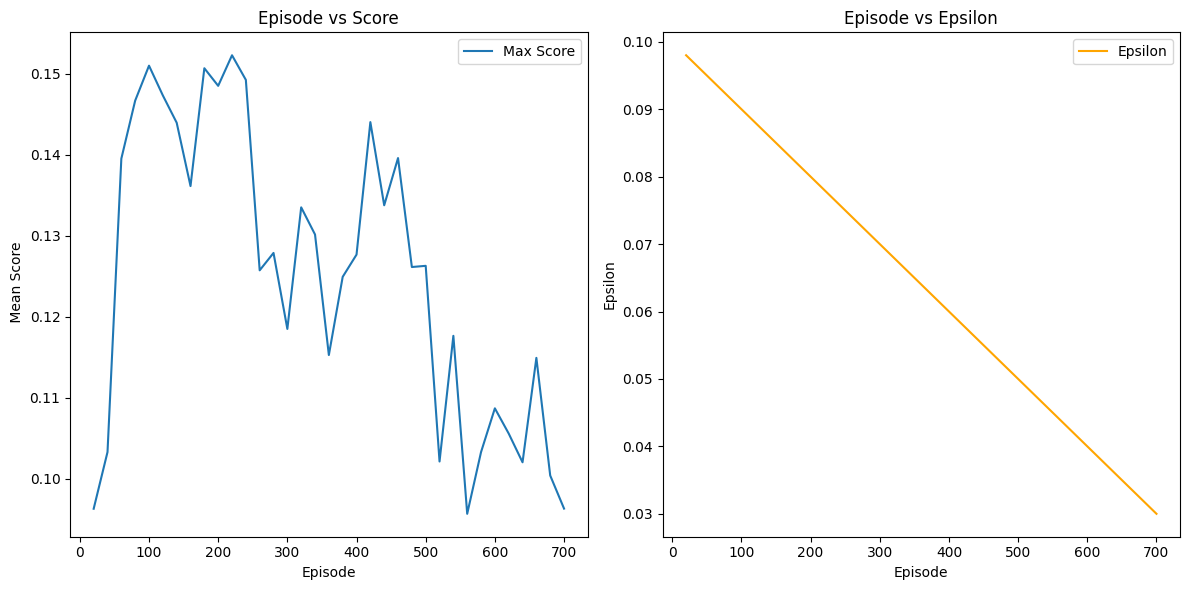

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the data from the CSV file
df = pd.read_csv('training_data.csv')

# Plot Episode vs. Max Score
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(df['Episode'], df['Score'], label='Max Score')
plt.xlabel('Episode')
plt.ylabel(' Mean Score')
plt.title('Episode vs Score')
plt.legend()

# Plot Episode vs. Epsilon
plt.subplot(1, 2, 2)
plt.plot(df['Episode'], df['TD '], label='Epsilon', color='orange')
plt.xlabel('Episode')
plt.ylabel('Epsilon')
plt.title('Episode vs Epsilon')
plt.legend()

plt.tight_layout()
plt.show()
